In [1]:
import re
import collections

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
COLOR_NOT_DISASTER = "#2a78d6"
COLOR_DISASTER = "#e34948"


# Disaster Tweets — Exploratory Data Analysis

Binary text classification: predict whether a tweet describes a real disaster (`target=1`) or not (`target=0`).
Files: `train.csv`, `test.csv`, `sample_submission.csv` — columns `id, keyword, location, text, target`.

## 1. Load data

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_submission.shape)
train.head()

train: (7613, 5)
test: (3263, 4)
sample_submission: (3263, 2)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


## 2. Overview & dtypes

In [3]:
train.info()
print()
print("id overlap between train/test:", len(set(train["id"]) & set(test["id"])))
print("fully duplicate rows in train:", train.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

id overlap between train/test: 0
fully duplicate rows in train: 0


## 3. Missing values

In [4]:
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_pct": (train.isna().mean() * 100).round(2),
    "test_missing": test.isna().sum(),
    "test_pct": (test.isna().mean() * 100).round(2),
})
missing

,train_missing,train_pct,test_missing,test_pct
id,0,0.00,0.0,0.00
keyword,61,0.80,26.0,0.80
location,2533,33.27,1105.0,33.86
target,0,0.00,NaN,NaN
text,0,0.00,0.0,0.00


## 4. Target distribution

        count    pct
target              
0        4342  57.03
1        3271  42.97


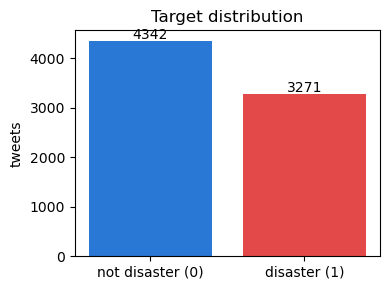

In [5]:
counts = train["target"].value_counts().sort_index()
pct = train["target"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"count": counts, "pct": pct.round(2)}))

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["not disaster (0)", "disaster (1)"], counts.values,
       color=[COLOR_NOT_DISASTER, COLOR_DISASTER])
ax.set_ylabel("tweets")
ax.set_title("Target distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 40, str(v), ha="center")
plt.tight_layout()
plt.show()

## 5. Duplicates & label noise

In [6]:
print("duplicate text rows:", train.duplicated(subset=["text"]).sum())

# texts that appear with more than one distinct target -> label noise
target_nunique = train.groupby("text")["target"].nunique()
conflicting_texts = target_nunique[target_nunique > 1].index
print("texts with conflicting labels:", len(conflicting_texts))

train[train["text"].isin(conflicting_texts)].sort_values("text").head(10)

duplicate text rows: 110
texts with conflicting labels: 18


,id,keyword,location,text,target
4290,6094,hellfire,"Jubail IC, Saudi Arabia.",#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,0
4299,6105,hellfire,?????? ??? ?????? ????????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,0
4312,6123,hellfire,?????? ???? ??????,#Allah describes piling up #wealth thinking it would last #forever as the description of the people of #Hellfire in ...,1
4244,6031,hazardous,"New Delhi, Delhi",#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,0
4221,5996,hazardous,NaN,#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
4239,6023,hazardous,"Mysore, Karnataka",#foodscare #offers2go #NestleIndia slips into loss after #Magginoodle #ban unsafe and hazardous for #humanconsumption,1
2832,4076,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,0
2831,4072,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1
2830,4068,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1
2833,4077,displaced,Pedophile hunting ground,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,1


## 6. Text length by class

char_len                                                 word_len  \
          count    mean    std   min   25%    50%    75%    max    count   
target                                                                     
0        4342.0   95.71  35.89   7.0  68.0  101.0  130.0  157.0   4342.0   
1        3271.0  108.11  29.31  14.0  88.0  115.0  136.0  151.0   3271.0   

                                                  
         mean   std  min   25%   50%   75%   max  
target                                            
0       14.70  6.16  1.0  10.0  15.0  19.0  31.0  
1       15.17  5.10  2.0  11.0  15.0  19.0  30.0

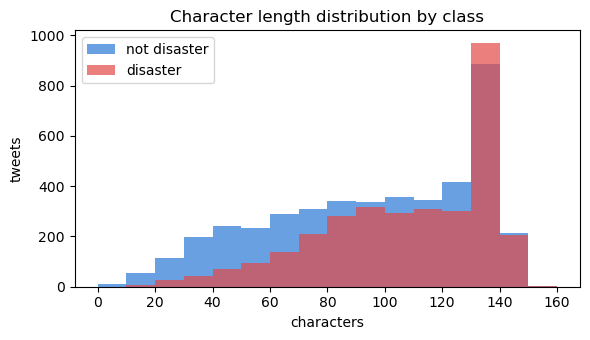

In [7]:
train["char_len"] = train["text"].str.len()
train["word_len"] = train["text"].str.split().str.len()

display(train.groupby("target")[["char_len", "word_len"]].describe().round(2))

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.linspace(0, 160, 17)
ax.hist(train.loc[train["target"] == 0, "char_len"], bins=bins, alpha=0.7,
        label="not disaster", color=COLOR_NOT_DISASTER)
ax.hist(train.loc[train["target"] == 1, "char_len"], bins=bins, alpha=0.7,
        label="disaster", color=COLOR_DISASTER)
ax.set_xlabel("characters")
ax.set_ylabel("tweets")
ax.set_title("Character length distribution by class")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Surface features: URLs, hashtags, mentions, punctuation

In [8]:
def count_pattern(s, pattern):
    return len(re.findall(pattern, s))

train["n_hashtags"] = train["text"].apply(lambda s: count_pattern(s, r"#\w+"))
train["n_mentions"] = train["text"].apply(lambda s: count_pattern(s, r"@\w+"))
train["n_urls"] = train["text"].apply(lambda s: count_pattern(s, r"http\S+"))
train["n_exclaim"] = train["text"].apply(lambda s: s.count("!"))
train["has_url"] = (train["n_urls"] > 0).astype(int)

surface_features = ["n_hashtags", "n_mentions", "n_urls", "n_exclaim", "has_url"]
train.groupby("target")[surface_features].mean().round(3)

,n_hashtags,n_mentions,n_urls,n_exclaim,has_url
target,,,,,
0,0.389,0.420,0.507,0.194,0.414
1,0.502,0.272,0.770,0.101,0.664


## 8. Keyword signal

`keyword` is nearly complete (0.8% missing) and shared between train/test — check how predictive it is on its own.

In [9]:
print("unique keywords (train):", train["keyword"].nunique())
print("unique keywords (test):", test["keyword"].nunique())
print("keywords shared between train/test:",
      len(set(train["keyword"].dropna()) & set(test["keyword"].dropna())))

kw_stats = (
    train.dropna(subset=["keyword"])
    .groupby("keyword")["target"]
    .agg(disaster_rate="mean", n="size")
)
kw_stats = kw_stats[kw_stats["n"] >= 15]  # drop rare keywords for reliability

print("\nTop 10 keywords by disaster rate (n>=15):")
display(kw_stats.sort_values("disaster_rate", ascending=False).head(10))

print("Bottom 10 keywords by disaster rate (n>=15):")
display(kw_stats.sort_values("disaster_rate", ascending=True).head(10))

unique keywords (train): 221
unique keywords (test): 221
keywords shared between train/test: 221

Top 10 keywords by disaster rate (n>=15):


,disaster_rate,n
keyword,,
derailment,1.000000,39
debris,1.000000,37
wreckage,1.000000,39
outbreak,0.975000,40
typhoon,0.973684,38
oil%20spill,0.973684,38
suicide%20bombing,0.969697,33
suicide%20bomber,0.967742,31
bombing,0.931034,29


Bottom 10 keywords by disaster rate (n>=15):


,disaster_rate,n
keyword,,
aftershock,0.000000,34
body%20bags,0.024390,41
ruin,0.027027,37
blazing,0.029412,34
body%20bag,0.030303,33
electrocute,0.031250,32
screaming,0.055556,36
traumatised,0.057143,35
panicking,0.060606,33


## 9. Location

`location` is 33% missing and mostly free text (3,341 unique values in 7,613 rows) — not usable without normalization.

In [10]:
print("unique locations (train):", train["location"].nunique())
print("missing locations (train):", train["location"].isna().sum())
train["location"].value_counts().head(10)

unique locations (train): 3341
missing locations (train): 2533


location
USA                104
New York            71
United States       50
London              45
Canada              29
Nigeria             28
UK                  27
Los Angeles, CA     26
India               24
Mumbai              22
Name: count, dtype: int64

## 10. Most frequent words by class

Lowercased, URLs stripped, stopwords removed, no stemming.

In [11]:
STOPWORDS = set("""
a an the this that these those is are was were be been being to of in on at for with and or but if not no
i you he she it we they my your his her its our their me him them us am do does did have has had will would can could
should just so than then there here what when where why how all any both each few more most other some such only own
same s t don now
""".split())


def tokenize(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    words = re.findall(r"[a-z']+", text)
    return [w for w in words if w not in STOPWORDS and len(w) > 2]


top_words = {}
for label, name in [(1, "disaster"), (0, "not_disaster")]:
    counter = collections.Counter()
    for t in train.loc[train["target"] == label, "text"]:
        counter.update(tokenize(t))
    top_words[name] = counter.most_common(15)

pd.DataFrame({
    "disaster": [f"{w} ({c})" for w, c in top_words["disaster"]],
    "not_disaster": [f"{w} ({c})" for w, c in top_words["not_disaster"]],
})

,disaster,not_disaster
0,from (245),like (254)
1,after (181),amp (209)
2,fire (178),out (198)
3,news (151),i'm (198)
4,amp (135),from (177)
5,over (128),new (171)
6,via (121),get (162)
7,disaster (120),about (139)
8,california (108),one (130)
9,police (108),don't (126)


## 11. Feature correlations

Correlation of the engineered numeric features (from sections 6–7) with each other and with `target`.

,char_len,word_len,n_hashtags,n_mentions,n_urls,n_exclaim,has_url,target
char_len,1.00,0.84,0.21,0.06,0.30,0.02,0.28,0.18
word_len,0.84,1.00,0.04,0.04,-0.12,0.04,-0.12,0.04
n_hashtags,0.21,0.04,1.00,-0.04,0.17,0.01,0.18,0.05
n_mentions,0.06,0.04,-0.04,1.00,-0.22,0.07,-0.23,-0.10
n_urls,0.30,-0.12,0.17,-0.22,1.00,-0.06,0.89,0.20
n_exclaim,0.02,0.04,0.01,0.07,-0.06,1.00,-0.06,-0.07
has_url,0.28,-0.12,0.18,-0.23,0.89,-0.06,1.00,0.25
target,0.18,0.04,0.05,-0.10,0.20,-0.07,0.25,1.00


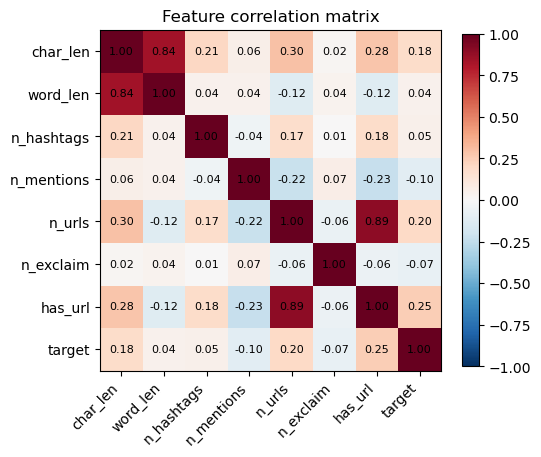

In [12]:
numeric_features = ["char_len", "word_len", "n_hashtags", "n_mentions", "n_urls", "n_exclaim", "has_url"]
corr = train[numeric_features + ["target"]].corr()
display(corr.round(2))

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Feature correlation matrix")
fig.colorbar(im, shrink=0.8)
plt.tight_layout()
plt.show()

## 12. Summary of EDA findings

- **Mild class imbalance**: 57% not-disaster / 43% disaster — stratified splits are sufficient, no resampling required.
- **`location` is largely unusable as-is**: 33% missing, 3,341 near-duplicate free-text values ("USA", "United States", "New York" counted separately). Needs normalization/geocoding or should be dropped.
- **`keyword` is a strong, cheap feature**: only 0.8% missing, 221 categories shared between train/test, per-keyword disaster rate ranges from 0% ("aftershock") to 100% ("derailment", "debris", "wreckage"). A keyword-rate encoding is a solid baseline feature.
- **Label noise**: duplicate texts exist with conflicting `target` values — worth a manual pass or a "drop conflicting duplicates" ablation before trusting CV scores.
- **Text length differs by class**: disaster tweets are longer on average (108 vs 96 chars) and tighter in spread.
- **Surface features carry weak but real signal**: disaster tweets contain a URL 66% of the time vs 41% for not-disaster; not-disaster tweets use more exclamation marks. Worth engineering as separate features even after stripping them from the raw text.
- **Engineered numeric features are only weakly correlated with each other** (no redundancy to worry about) and each has a small-to-moderate correlation with `target` individually — none is strong enough alone, but combined with the raw text they're useful signal for a baseline model.

# Baseline model

Goal: a working proof-of-concept, not a tuned/SOTA model. Pipeline: TF-IDF over `text` + the
engineered numeric features from the EDA above, fed into a `RandomForestClassifier` with
untuned/default-ish hyperparameters.

## 13. Train / validation split

In [13]:
from sklearn.model_selection import train_test_split

feature_cols = ["text"] + numeric_features
X = train[feature_cols]
y = train["target"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape, "val:", X_val.shape)

train: (6090, 8) val: (1523, 8)


## 14. Feature pipeline & model

`ColumnTransformer` handles both feature types in one fitted object, so the whole thing (vectorizer +
scaler + classifier) can be pickled and reused as a single unit at inference time.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english"), "text"),
    ("numeric", StandardScaler(), numeric_features),
])

baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'text'),
                                                 ('numeric', StandardScaler(),
                                                  ['char_len', 'word_len',
                                                   'n_hashtags', 'n_mentions',
                                                   'n_urls', 'n_exclaim',
                                                   'has_url'])])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

## 15. Evaluate on the validation split

accuracy: 0.777
f1:       0.701

              precision    recall  f1-score   support

not disaster       0.75      0.90      0.82       869
    disaster       0.83      0.61      0.70       654

    accuracy                           0.78      1523
   macro avg       0.79      0.76      0.76      1523
weighted avg       0.79      0.78      0.77      1523



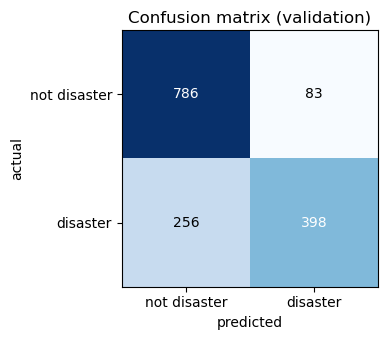

In [15]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

y_pred = baseline_model.predict(X_val)

print(f"accuracy: {accuracy_score(y_val, y_pred):.3f}")
print(f"f1:       {f1_score(y_val, y_pred):.3f}")
print()
print(classification_report(y_val, y_pred, target_names=["not disaster", "disaster"]))

cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["not disaster", "disaster"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["not disaster", "disaster"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix (validation)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

## 16. Save model weights

Pickle the whole fitted pipeline (TF-IDF vectorizer + scaler + Random Forest) with `joblib` so it can
be reloaded and used for inference without refitting.

In [16]:
import joblib

MODEL_PATH = "baseline_model.pkl"
joblib.dump(baseline_model, MODEL_PATH)
print(f"saved {MODEL_PATH}")

# sanity check: reload and confirm predictions match
reloaded = joblib.load(MODEL_PATH)
assert (reloaded.predict(X_val) == y_pred).all()
print("reload check passed")

saved baseline_model.pkl


reload check passed


## 17. Bonus: predict on `test.csv` and write a submission file

Reuses the same feature-engineering logic from the EDA section on `test`, then runs the saved model.

In [17]:
test["char_len"] = test["text"].str.len()
test["word_len"] = test["text"].str.split().str.len()
test["n_hashtags"] = test["text"].apply(lambda s: count_pattern(s, r"#\w+"))
test["n_mentions"] = test["text"].apply(lambda s: count_pattern(s, r"@\w+"))
test["n_urls"] = test["text"].apply(lambda s: count_pattern(s, r"http\S+"))
test["n_exclaim"] = test["text"].apply(lambda s: s.count("!"))
test["has_url"] = (test["n_urls"] > 0).astype(int)

test_preds = reloaded.predict(test[feature_cols])

submission = sample_submission.copy()
submission["target"] = test_preds
submission.to_csv("submission.csv", index=False)
print("saved submission.csv")
submission.head()

saved submission.csv


,id,target
0,0,0
1,2,1
2,3,1
3,9,0
4,11,1


# Stronger baseline

The Random Forest above tops out around F1 0.70. Tree ensembles generally underperform on
**high-dimensional, sparse TF-IDF features** — most of the ~5,000 columns are zero for any given
row, and trees split one feature at a time, so they need many splits to approximate what a linear
model gets in one step. Linear models (`LogisticRegression`, `LinearSVC`) are the standard strong,
fast baseline for bag-of-words text classification, and this is exactly the class of problem where
they tend to beat tree ensembles outright — this is also what most strong public kernels for this
Kaggle competition are built on.

Three upgrades over the first baseline, still well within "no hours of tuning":
1. **Word + character n-gram TF-IDF** — char n-grams (3–5 chars) pick up hashtags, misspellings, and
   word fragments (e.g. `#earthquake`, `#wildfires`) that word-level tokenization alone misses.
2. **`keyword` as a one-hot feature** — section 8 showed it's individually very predictive (0%–100%
   disaster rate per keyword); it was left out of the first baseline entirely.
3. **A quick cross-validated bake-off** between Logistic Regression, Linear SVM, and the original
   Random Forest, so the "stronger" choice is picked on evidence rather than assumed.

## 18. Clean `keyword` and assemble the richer feature set

In [18]:
# the raw keyword column has URL-encoded spaces (e.g. "oil%20spill") and 0.8% missing values
for _df in (train, test):
    _df["keyword"] = _df["keyword"].fillna("missing").str.replace("%20", " ", regex=False)

feature_cols2 = ["text", "keyword"] + numeric_features
X2 = train[feature_cols2]

X2_train, X2_val, y_train, y_val = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X2_train.shape, "val:", X2_val.shape)
assert list(X2_train.index) == list(X_train.index), "split should match the first baseline's split"

train: (6090, 9) val: (1523, 9)


## 19. Model bake-off (5-fold cross-validated F1, on the training split only)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score


def build_preprocessor():
    return ColumnTransformer([
        ("tfidf_word", TfidfVectorizer(ngram_range=(1, 2), max_features=5000,
                                        min_df=2, sublinear_tf=True), "text"),
        ("tfidf_char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                        max_features=3000, sublinear_tf=True), "text"),
        ("keyword", OneHotEncoder(handle_unknown="ignore"), ["keyword"]),
        ("numeric", StandardScaler(), numeric_features),
    ])


candidates = {
    "logistic_regression": LogisticRegression(max_iter=1000),
    "linear_svc": LinearSVC(max_iter=5000),
    "random_forest (baseline)": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("preprocess", build_preprocessor()), ("clf", clf)])
    scores = cross_val_score(pipe, X2_train, y_train, cv=cv, scoring="f1", n_jobs=1)
    cv_results[name] = scores
    print(f"{name:28s} f1 = {scores.mean():.3f} +/- {scores.std():.3f}")

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nbest candidate: {best_name} (mean f1 = {cv_results[best_name].mean():.3f})")

logistic_regression          f1 = 0.764 +/- 0.012


C:\Users\TTest\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


linear_svc                   f1 = 0.736 +/- 0.014


random_forest (baseline)     f1 = 0.708 +/- 0.014

best candidate: logistic_regression (mean f1 = 0.764)


## 20. Fit the winning model on the full training split and evaluate

[baseline v1 - random forest]   accuracy: 0.777  f1: 0.701
[strong baseline - logistic_regression]  accuracy: 0.814  f1: 0.773

              precision    recall  f1-score   support

not disaster       0.81      0.87      0.84       869
    disaster       0.81      0.74      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.81      1523
weighted avg       0.81      0.81      0.81      1523



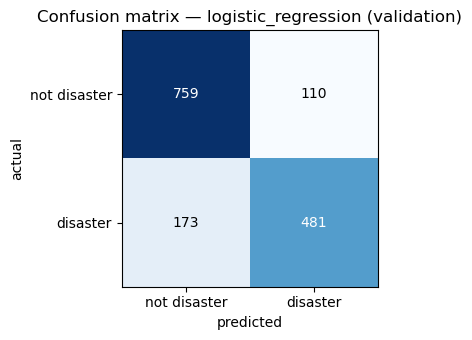

In [20]:
strong_model = Pipeline([
    ("preprocess", build_preprocessor()),
    ("clf", candidates[best_name]),
])
strong_model.fit(X2_train, y_train)

y_pred2 = strong_model.predict(X2_val)

print(f"[baseline v1 - random forest]   accuracy: {accuracy_score(y_val, y_pred):.3f}  f1: {f1_score(y_val, y_pred):.3f}")
print(f"[strong baseline - {best_name}]  accuracy: {accuracy_score(y_val, y_pred2):.3f}  f1: {f1_score(y_val, y_pred2):.3f}")
print()
print(classification_report(y_val, y_pred2, target_names=["not disaster", "disaster"]))

cm2 = confusion_matrix(y_val, y_pred2)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm2, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["not disaster", "disaster"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["not disaster", "disaster"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title(f"Confusion matrix — {best_name} (validation)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm2[i, j], ha="center", va="center",
                color="white" if cm2[i, j] > cm2.max() / 2 else "black")
plt.tight_layout()
plt.show()

## 21. Save the stronger model's weights

In [21]:
STRONG_MODEL_PATH = "strong_baseline_model.pkl"
joblib.dump(strong_model, STRONG_MODEL_PATH)
print(f"saved {STRONG_MODEL_PATH}")

reloaded_strong = joblib.load(STRONG_MODEL_PATH)
assert (reloaded_strong.predict(X2_val) == y_pred2).all()
print("reload check passed")

saved strong_baseline_model.pkl


reload check passed


## 22. Regenerate the Kaggle submission with the stronger model

Overwrites `submission.csv` from the first baseline — this is the file to submit to the competition.

In [22]:
test_preds2 = reloaded_strong.predict(test[feature_cols2])

submission = sample_submission.copy()
submission["target"] = test_preds2
submission.to_csv("submission.csv", index=False)
print("saved submission.csv (stronger model)")
print("predicted disaster rate on test:", submission["target"].mean().round(3))
submission.head()

saved submission.csv (stronger model)
predicted disaster rate on test: 0.377


,id,target
0,0,1
1,2,0
2,3,1
3,9,1
4,11,1


# LLM prompt baseline

A third approach: instead of training anything, **prompt a small pretrained LLM** to classify each
tweet directly, zero-shot. No labeled training data needed at inference time — only the prompt.

**Hardware constraint**: this machine is CPU-only (no CUDA GPU), 8 cores, ~17GB RAM. That rules out
anything model-of-the-week-sized; the model has to be small enough to run generation in well under a
second per example on CPU. Two candidates were sanity-checked on 8 hand-picked examples (mix of clear
disasters, clear non-disasters, and figurative "fire"/"disaster" language) before committing to a
full run:

| Model | Params | Result |
|---|---|---|
| `google/flan-t5-small` | 80M | **Degenerate** — predicted the same class for all 8 examples regardless of prompt wording (2 prompt formats tried). Too weak for this task at this size. |
| `Qwen/Qwen2.5-0.5B-Instruct` | 0.5B | Real discrimination — 5/8 correct, sensible mix of yes/no, ~0.7s/example on CPU. |

**`Qwen2.5-0.5B-Instruct`** it is — small, free, local, CPU-friendly (~1GB one-time download, cached
by `transformers`), no API key, no per-request cost, no data leaving the machine.

## Prompt-improvement ablation (and a negative result worth keeping)

The obvious next move is few-shot prompting. On the 8 hand-picked sanity examples it looked like a
clean win — 6 in-context examples (3 disasters, 3 disaster-*flavored* non-disasters: sarcasm, slang,
metaphor) took the score from 5/8 to a perfect 8/8, fixing exactly the false positives zero-shot made
("my heart is on fire for you babe", "this traffic is a disaster", etc.).

That result **did not hold up** on a real 60-tweet stratified sample from the validation set:

| Prompt variant | F1 (same 60-tweet sample) | Predicted-positive rate |
|---|---|---|
| **Zero-shot** | **0.741** | 0.80 |
| 2-shot (1 example per class) | 0.618 | 0.37 |
| 6-shot v1 (synthetic, news-style positives / casual negatives) | 0.108 | very low |
| 6-shot v2 (both classes rewritten in matched casual/tweet register) | ~0.20 | very low |

Performance gets **monotonically worse as more few-shot examples are added** — the opposite of the
usual expectation. Two likely causes: (1) at 0.5B parameters, the model doesn't reliably generalize
from a handful of in-context examples — it anchors on shallow, superficial similarity to whichever
examples happen to be in the prompt rather than the underlying rule, and (2) the tiny hand-picked
8-example sanity set was itself not representative enough to catch this — it happened to reward the
few-shot prompt because all 8 examples were relatively clean/prototypical, while the real dataset is
much messier. **Lesson**: at this model scale, validate prompt changes on a real, reasonably sized
sample before trusting a small hand-picked sanity check — and "more context" is not automatically
better for small models.

**Zero-shot wins empirically and is what the rest of this section uses.**

## 23. Load the model and define the prompt

In [23]:
%pip install -q transformers sentencepiece accelerate

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

LLM_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
llm_tokenizer = AutoTokenizer.from_pretrained(LLM_NAME)
llm_model = AutoModelForCausalLM.from_pretrained(LLM_NAME, dtype=torch.float32)
llm_model.eval()

LLM_SYSTEM_PROMPT = (
    "You are a strict binary classifier. Given a tweet, decide whether it describes a REAL "
    "disaster, accident, or emergency (not sarcasm, a joke, a metaphor, song lyrics, or unrelated "
    "use of a disaster-like word). Reply with exactly one word: yes or no."
)


@torch.inference_mode()
def llm_classify(text):
    messages = [
        {"role": "system", "content": LLM_SYSTEM_PROMPT},
        {"role": "user", "content": f"Tweet: {text}"},
    ]
    prompt = llm_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = llm_tokenizer(prompt, return_tensors="pt")
    out_ids = llm_model.generate(
        **inputs, max_new_tokens=3, do_sample=False, pad_token_id=llm_tokenizer.eos_token_id
    )
    new_tokens = out_ids[0][inputs["input_ids"].shape[1]:]
    answer = llm_tokenizer.decode(new_tokens, skip_special_tokens=True).strip().lower()
    return 1 if answer.startswith("yes") else 0


# smoke test
print(llm_classify("Forest fire near La Ronge Sask. Canada"))  # expect 1
print(llm_classify("I just love this song, it is fire!"))       # expect 0

Note: you may need to restart the kernel to use updated packages.


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

1


0


## 24. Run on a validation subsample

Full CPU generation over all 1,523 validation rows would take ~18 minutes at ~0.7s/example — fine to
run, but overkill for a proof of concept. Evaluating on a stratified random subsample keeps this
section fast while still giving a meaningful accuracy/F1 estimate.

In [24]:
import time

N_LLM_SAMPLE = 200
llm_sample_idx, _ = train_test_split(
    X2_val.index, train_size=N_LLM_SAMPLE, random_state=42, stratify=y_val
)
llm_texts = train.loc[llm_sample_idx, "text"]
llm_true = train.loc[llm_sample_idx, "target"]

t0 = time.time()
llm_preds = [llm_classify(t) for t in llm_texts]
elapsed = time.time() - t0
print(f"classified {len(llm_texts)} tweets in {elapsed:.1f}s ({elapsed/len(llm_texts):.2f}s/example)")

classified 200 tweets in 335.4s (1.68s/example)


## 25. Evaluate and compare against the trained baselines

In [25]:
print("LLM zero-shot prompt — classification report (n=200 sample):")
print(classification_report(llm_true, llm_preds, target_names=["not disaster", "disaster"]))

# re-score the two trained baselines on this SAME 200-row sample for a fair side-by-side
baseline_sample_pred = baseline_model.predict(train.loc[llm_sample_idx, feature_cols])
strong_sample_pred = strong_model.predict(train.loc[llm_sample_idx, feature_cols2])

comparison = pd.DataFrame({
    "model": [
        "random forest (baseline v1)",
        f"{best_name} (stronger baseline)",
        "Qwen2.5-0.5B-Instruct (0-shot prompt)",
    ],
    "f1_on_200_sample": [
        f1_score(llm_true, baseline_sample_pred),
        f1_score(llm_true, strong_sample_pred),
        f1_score(llm_true, llm_preds),
    ],
    "accuracy_on_200_sample": [
        accuracy_score(llm_true, baseline_sample_pred),
        accuracy_score(llm_true, strong_sample_pred),
        accuracy_score(llm_true, llm_preds),
    ],
    "f1_on_full_1523_val_reference": [f1_score(y_val, y_pred), f1_score(y_val, y_pred2), np.nan],
}).round(3)
comparison

LLM zero-shot prompt — classification report (n=200 sample):
              precision    recall  f1-score   support

not disaster       0.80      0.21      0.33       114
    disaster       0.47      0.93      0.62        86

    accuracy                           0.52       200
   macro avg       0.64      0.57      0.48       200
weighted avg       0.66      0.52      0.46       200



,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
0,random forest (baseline v1),0.753,0.81,0.701
1,logistic_regression (stronger baseline),0.807,0.84,0.773
2,Qwen2.5-0.5B-Instruct (0-shot prompt),0.625,0.52,NaN


## 26. Does a bigger model help? `Qwen2.5-1.5B-Instruct`

Same zero-shot prompt, same 200-tweet sample, 3x the parameters (~3GB download instead of ~1GB, still
CPU-only). If prompting-based classification is going to close the gap with the trained baseline,
scale is the most obvious lever to pull next.

In [26]:
LLM_NAME_LARGE = "Qwen/Qwen2.5-1.5B-Instruct"
llm_tokenizer_large = AutoTokenizer.from_pretrained(LLM_NAME_LARGE)
llm_model_large = AutoModelForCausalLM.from_pretrained(LLM_NAME_LARGE, dtype=torch.float32)
llm_model_large.eval()


@torch.inference_mode()
def llm_classify_large(text):
    messages = [
        {"role": "system", "content": LLM_SYSTEM_PROMPT},
        {"role": "user", "content": f"Tweet: {text}"},
    ]
    prompt = llm_tokenizer_large.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = llm_tokenizer_large(prompt, return_tensors="pt")
    out_ids = llm_model_large.generate(
        **inputs, max_new_tokens=3, do_sample=False, pad_token_id=llm_tokenizer_large.eos_token_id
    )
    new_tokens = out_ids[0][inputs["input_ids"].shape[1]:]
    answer = llm_tokenizer_large.decode(new_tokens, skip_special_tokens=True).strip().lower()
    return 1 if answer.startswith("yes") else 0


t0 = time.time()
llm_preds_large = [llm_classify_large(t) for t in llm_texts]
elapsed = time.time() - t0
print(f"classified {len(llm_texts)} tweets in {elapsed:.1f}s ({elapsed/len(llm_texts):.2f}s/example)")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

classified 200 tweets in 709.1s (3.55s/example)


In [27]:
print("Qwen2.5-1.5B-Instruct — classification report (same n=200 sample):")
print(classification_report(llm_true, llm_preds_large, target_names=["not disaster", "disaster"]))

comparison_with_large = pd.concat([
    comparison,
    pd.DataFrame([{
        "model": "Qwen2.5-1.5B-Instruct (0-shot prompt)",
        "f1_on_200_sample": f1_score(llm_true, llm_preds_large),
        "accuracy_on_200_sample": accuracy_score(llm_true, llm_preds_large),
        "f1_on_full_1523_val_reference": np.nan,
    }]),
], ignore_index=True).round(3)
comparison_with_large

Qwen2.5-1.5B-Instruct — classification report (same n=200 sample):
              precision    recall  f1-score   support

not disaster       0.70      0.94      0.80       114
    disaster       0.85      0.47      0.60        86

    accuracy                           0.73       200
   macro avg       0.78      0.70      0.70       200
weighted avg       0.76      0.73      0.72       200



,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
0,random forest (baseline v1),0.753,0.810,0.701
1,logistic_regression (stronger baseline),0.807,0.840,0.773
2,Qwen2.5-0.5B-Instruct (0-shot prompt),0.625,0.520,NaN
3,Qwen2.5-1.5B-Instruct (0-shot prompt),0.602,0.735,NaN


## 28. Combining the models: does ensembling help?

The two LLMs have near-opposite error profiles on the same 200 tweets — 0.5B over-predicts "disaster"
(precision 0.47, recall 0.93), 1.5B under-predicts it (precision 0.85, recall 0.47). That complementary
pattern is exactly the setup where ensembling sometimes helps. Five hard-vote combinations, all
evaluated on the same 200-tweet sample so they're directly comparable to the table above:

1. **LLM AND** — both 0.5B and 1.5B must say "disaster".
2. **LLM OR** — either says "disaster".
3. **3-way majority** — LR (stronger baseline) + 0.5B + 1.5B, 2 of 3 wins.
4. **LR, overridden to "disaster" if both LLMs agree** — trust LR, but let a unanimous LLM vote flip a
   "not disaster" call.
5. **LR, but only counted "disaster" if at least one LLM agrees** — trust LR, but require LLM backup
   before calling "disaster" (a false-positive filter on LR).

In [28]:
llm_05b = np.array(llm_preds)
llm_15b = np.array(llm_preds_large)
lr_pred = np.array(strong_sample_pred)  # stronger baseline's predictions on this same 200-sample

ensemble_strategies = {
    "LLM AND (0.5B & 1.5B)": (llm_05b & llm_15b),
    "LLM OR (0.5B | 1.5B)": (llm_05b | llm_15b),
    "majority vote: LR + 0.5B + 1.5B": (((lr_pred + llm_05b + llm_15b) >= 2).astype(int)),
    "LR, override to disaster if both LLMs agree": (lr_pred | (llm_05b & llm_15b)),
    "LR, require >=1 LLM to agree on disaster": (lr_pred & (llm_05b | llm_15b)),
}

ensemble_rows = []
for name, preds in ensemble_strategies.items():
    ensemble_rows.append({
        "model": name,
        "f1_on_200_sample": f1_score(llm_true, preds),
        "accuracy_on_200_sample": accuracy_score(llm_true, preds),
        "f1_on_full_1523_val_reference": np.nan,
    })

all_results = pd.concat(
    [comparison_with_large, pd.DataFrame(ensemble_rows)], ignore_index=True
).round(3)
all_results.sort_values("f1_on_200_sample", ascending=False)

,model,f1_on_200_sample,accuracy_on_200_sample,f1_on_full_1523_val_reference
1,logistic_regression (stronger baseline),0.807,0.840,0.773
7,"LR, override to disaster if both LLMs agree",0.805,0.830,NaN
8,"LR, require >=1 LLM to agree on disaster",0.790,0.830,NaN
6,majority vote: LR + 0.5B + 1.5B,0.788,0.820,NaN
0,random forest (baseline v1),0.753,0.810,0.701
2,Qwen2.5-0.5B-Instruct (0-shot prompt),0.625,0.520,NaN
5,LLM OR (0.5B | 1.5B),0.623,0.515,NaN
4,LLM AND (0.5B & 1.5B),0.606,0.740,NaN
3,Qwen2.5-1.5B-Instruct (0-shot prompt),0.602,0.735,NaN


## 29. Takeaway so far: three approaches, three tradeoffs, and does combining them help?

- **Trained TF-IDF + Logistic Regression** (section 20) is the best performer so far (F1 ≈ 0.77–0.81
  depending on sample) and the cheapest to run at inference time — a few milliseconds per tweet, no
  GPU, tiny model file. It needs ~6,000 labeled examples to train, which this competition provides.
- **Trained TF-IDF + Random Forest** (section 15) is worse than the linear model on this kind of
  sparse text data, and its pickle is >100x larger for no accuracy benefit — kept as the "first,
  naive" baseline for comparison, not recommended as the final choice.
- **Zero-shot LLM prompting (0.5B)** trails the trained linear model by a wide margin (F1 ≈ 0.62 vs
  ≈ 0.81) and costs far more compute per prediction (~0.7s vs ~1ms).
- **Few-shot prompting made the small model *worse*, not better** — a reminder that "add examples to
  the prompt" is a heuristic, not a guarantee, especially below ~1B parameters.
- **A 3x bigger model (1.5B) didn't help either — it just traded the failure mode**: accuracy improved
  but F1 stayed flat or slightly dropped, because it swung from over-predicting "disaster" to
  under-predicting it.
- **Ensembling the two LLMs, and blending them with the trained baseline, was tested in section 28**
  — nothing beat plain Logistic Regression alone.

None of this used a *pretrained transformer's own language understanding* — TF-IDF is bag-of-words,
and prompting a frozen LLM never trains on this competition's labels at all. The sections below try
that: first a frozen-RoBERTa linear probe, then actually fine-tuning RoBERTa on the labels. See the
final takeaway at the end of the notebook for which model `submission.csv` ends up built from.

# RoBERTa: from linear probe to real fine-tuning

`RoBERTa-base` is a transformer pretrained on a large text corpus with masked-language-modeling —
unlike the LLM sections above, we're not prompting it in natural language; we're going to use its
internal representations directly, two different ways.

## 30. Linear probe: freeze RoBERTa, train only a classifier head

Freeze RoBERTa-base entirely, run each tweet through it once (no gradient, no backprop) to get a
mean-pooled 768-dim embedding, then train a plain `LogisticRegression` on top of those frozen
embeddings. This was run standalone earlier this session; the embeddings and fitted classifier are
cached on disk, so this cell reloads them rather than recomputing (~450s saved).

In [ ]:
roberta_train_emb = np.load("roberta_train_emb.npy")
roberta_val_emb = np.load("roberta_val_emb.npy")
roberta_test_emb = np.load("roberta_test_emb.npy")
print("embedding shapes (train, val, test):", roberta_train_emb.shape, roberta_val_emb.shape, roberta_test_emb.shape)

roberta_probe = joblib.load("roberta_linear_probe.pkl")  # fit on the train split only, for a fair val comparison
probe_val_pred = roberta_probe.predict(roberta_val_emb)

print(f"\nRoBERTa-base linear probe — full val split (n={len(y_val)}):")
print(f"accuracy: {accuracy_score(y_val, probe_val_pred):.3f}  f1: {f1_score(y_val, probe_val_pred):.3f}")
print(classification_report(y_val, probe_val_pred, target_names=["not disaster", "disaster"]))

# same 200-sample used throughout, via positional lookup into the val embeddings (no recompute needed)
val_pos = X_val.index.get_indexer(llm_sample_idx)
probe_sample_pred = roberta_probe.predict(roberta_val_emb[val_pos])
print(f"On the same 200-sample: accuracy {accuracy_score(llm_true, probe_sample_pred):.3f}  "
      f"f1 {f1_score(llm_true, probe_sample_pred):.3f}")

all_results = pd.concat([all_results, pd.DataFrame([{
    "model": "RoBERTa-base linear probe (frozen)",
    "f1_on_200_sample": f1_score(llm_true, probe_sample_pred),
    "accuracy_on_200_sample": accuracy_score(llm_true, probe_sample_pred),
    "f1_on_full_1523_val_reference": f1_score(y_val, probe_val_pred),
}])], ignore_index=True)
all_results.sort_values("f1_on_200_sample", ascending=False).round(3)

## 31. Real fine-tuning: full fine-tune vs. LoRA

The linear probe never updates RoBERTa's own weights — only a small `LogisticRegression` head on
top of frozen embeddings. Real fine-tuning unfreezes RoBERTa and backpropagates through it, so the
transformer itself adapts to disaster-tweet-specific patterns. Public kernels for this competition
report ~0.83–0.84 F1 doing exactly this.

**Two ways to fine-tune were benchmarked (8 real training steps each) before committing to a full
run**, since this machine is CPU-only with limited free RAM:

| Approach | Trainable params | Speed | Peak process memory |
|---|---|---|---|
| Full fine-tune (all 12 layers unfrozen) | 125M (100%) | 355 ms/example | **3.11 GB** |
| LoRA (rank 8, query+value projections only) | 887K (0.7%) | **186 ms/example** | **0.93 GB** |

At the time of benchmarking, only **3.3GB RAM was free** on this machine. Full fine-tuning was
already using essentially all of it after 4 training steps — a real risk of hitting swap (which
would make training far slower than any time estimate, silently) or an outright crash losing all
progress. LoRA came out **both ~1.9x faster and ~3.3x lighter on memory** in the same benchmark —
not just a safety fallback here, but the empirically better choice on this hardware. The rest of
this section fine-tunes with LoRA.

## 32. Set up the LoRA-wrapped model

In [ ]:
%pip install -q peft

from transformers import AutoTokenizer, RobertaForSequenceClassification, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, PeftModel, TaskType
from torch.optim import AdamW

roberta_tok = AutoTokenizer.from_pretrained("roberta-base")

# tweets are short — check the real token-length distribution rather than guessing max_length
sample_lens = np.array([len(roberta_tok.encode(t)) for t in train["text"].sample(500, random_state=0)])
print(f"token length — mean: {sample_lens.mean():.1f}  p95: {np.percentile(sample_lens, 95):.0f}  max: {sample_lens.max()}")

MAX_LENGTH = 64   # comfortably covers p95 with margin
BATCH_SIZE = 8    # matches the memory-benchmarked configuration above
EPOCHS = 3

base_clf_model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8, lora_alpha=16, lora_dropout=0.1,
    target_modules=["query", "value"],
)
lora_model = get_peft_model(base_clf_model, lora_config)
lora_model.print_trainable_parameters()

## 33. Train (3 epochs, checkpoint + evaluate after each)

Manual PyTorch loop, matching the style used elsewhere in this notebook rather than the `Trainer`
API. Each epoch is checkpointed to disk immediately after its validation pass — this is a genuinely
long-running CPU job, so progress is never lost partway through, and the best-scoring epoch (not
necessarily the last one) is what gets used going forward.

In [ ]:
def evaluate_lora(model, texts, batch_size=32):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            enc = roberta_tok(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
            out = model(**enc)
            preds.extend(out.logits.argmax(dim=-1).tolist())
    model.train()
    return preds


train_texts = train.loc[X_train.index, "text"].tolist()
train_labels = train.loc[X_train.index, "target"].tolist()
val_texts = train.loc[X_val.index, "text"].tolist()
val_labels_list = train.loc[X_val.index, "target"].tolist()

n_train = len(train_texts)
steps_per_epoch = n_train // BATCH_SIZE
total_steps = steps_per_epoch * EPOCHS

trainable_params = [p for p in lora_model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_params, lr=2e-4, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
)

epoch_results = []
overall_t0 = time.time()
lora_model.train()

for epoch in range(1, EPOCHS + 1):
    epoch_t0 = time.time()
    running_loss = 0.0
    perm = np.random.RandomState(epoch).permutation(n_train)

    for step in range(steps_per_epoch):
        idx = perm[step * BATCH_SIZE:(step + 1) * BATCH_SIZE]
        batch_texts = [train_texts[i] for i in idx]
        batch_labels = torch.tensor([train_labels[i] for i in idx])

        enc = roberta_tok(batch_texts, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
        out = lora_model(**enc, labels=batch_labels)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_params, 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        running_loss += loss.item()

        if (step + 1) % 100 == 0:
            print(f"  epoch {epoch} step {step + 1}/{steps_per_epoch}  "
                  f"avg_loss={running_loss / (step + 1):.4f}  elapsed={time.time() - epoch_t0:.0f}s", flush=True)

    epoch_dt = time.time() - epoch_t0
    val_preds = evaluate_lora(lora_model, val_texts)
    val_f1 = f1_score(val_labels_list, val_preds)
    val_acc = accuracy_score(val_labels_list, val_preds)
    print(f"epoch {epoch} done in {epoch_dt:.0f}s ({epoch_dt / 60:.1f} min) — "
          f"val accuracy {val_acc:.3f}  val f1 {val_f1:.3f}", flush=True)

    ckpt_path = f"roberta_lora_epoch{epoch}"
    lora_model.save_pretrained(ckpt_path)
    epoch_results.append({"epoch": epoch, "val_f1": val_f1, "val_acc": val_acc, "checkpoint": ckpt_path})

print(f"\ntotal training time: {(time.time() - overall_t0) / 60:.1f} min")
pd.DataFrame(epoch_results)

## 34. Pick the best epoch and evaluate

In [ ]:
best_epoch = max(epoch_results, key=lambda r: r["val_f1"])
print("best epoch by validation F1:", best_epoch)

best_base = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
best_lora_model = PeftModel.from_pretrained(best_base, best_epoch["checkpoint"])
best_lora_model.eval()

final_val_preds = evaluate_lora(best_lora_model, val_texts)
lora_full_val_f1 = f1_score(val_labels_list, final_val_preds)
lora_full_val_acc = accuracy_score(val_labels_list, final_val_preds)

print(f"\nRoBERTa + LoRA fine-tune — full val split (n={len(val_labels_list)}):")
print(f"accuracy: {lora_full_val_acc:.3f}  f1: {lora_full_val_f1:.3f}")
print(classification_report(val_labels_list, final_val_preds, target_names=["not disaster", "disaster"]))

# same 200-sample used throughout the notebook
sample_texts_200 = train.loc[llm_sample_idx, "text"].tolist()
sample_preds_200 = evaluate_lora(best_lora_model, sample_texts_200)
lora_sample_f1 = f1_score(llm_true, sample_preds_200)
lora_sample_acc = accuracy_score(llm_true, sample_preds_200)
print(f"\nOn the same 200-sample: accuracy {lora_sample_acc:.3f}  f1 {lora_sample_f1:.3f}")

cm3 = confusion_matrix(val_labels_list, final_val_preds)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm3, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["not disaster", "disaster"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["not disaster", "disaster"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title("Confusion matrix — RoBERTa + LoRA (validation)")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm3[i, j], ha="center", va="center",
                color="white" if cm3[i, j] > cm3.max() / 2 else "black")
plt.tight_layout()
plt.show()

all_results = pd.concat([all_results, pd.DataFrame([{
    "model": f"RoBERTa + LoRA fine-tune (epoch {best_epoch['epoch']})",
    "f1_on_200_sample": lora_sample_f1,
    "accuracy_on_200_sample": lora_sample_acc,
    "f1_on_full_1523_val_reference": lora_full_val_f1,
}])], ignore_index=True)
all_results.sort_values("f1_on_200_sample", ascending=False).round(3)

## 35. Save the final fine-tuned weights

`PeftModel.save_pretrained` writes only the LoRA adapter (the small trainable matrices) plus its
config, not a full copy of RoBERTa-base — so this artifact stays small even though it represents a
genuinely fine-tuned model. Reconstructing it for inference means loading plain `roberta-base` and
applying this adapter on top, same as the loading step in section 34.

In [ ]:
import os

FINAL_LORA_PATH = "roberta_lora_final"
best_lora_model.save_pretrained(FINAL_LORA_PATH)
roberta_tok.save_pretrained(FINAL_LORA_PATH)

size_mb = sum(os.path.getsize(os.path.join(FINAL_LORA_PATH, f)) for f in os.listdir(FINAL_LORA_PATH)) / 1e6
print(f"saved {FINAL_LORA_PATH}/ (LoRA adapter + tokenizer) — {size_mb:.1f} MB")
print("files:", os.listdir(FINAL_LORA_PATH))

## 36. Regenerate the submission with whichever RoBERTa variant wins

Compares the LoRA fine-tune against the linear probe on the full validation set (the larger, more
reliable sample) and writes `submission.csv` from whichever one actually validates better — not
assumed in advance.

In [ ]:
probe_full_val_f1 = f1_score(y_val, probe_val_pred)

print(f"RoBERTa linear probe      full-val F1: {probe_full_val_f1:.3f}")
print(f"RoBERTa + LoRA fine-tune  full-val F1: {lora_full_val_f1:.3f}")

if lora_full_val_f1 > probe_full_val_f1:
    print("\nLoRA fine-tune wins on full-val F1 — regenerating submission.csv from it")
    test_texts = test["text"].tolist()
    test_preds_lora = evaluate_lora(best_lora_model, test_texts)
    submission = sample_submission.copy()
    submission["target"] = test_preds_lora
    submission.to_csv("submission.csv", index=False)
    winning_model_name = f"RoBERTa + LoRA fine-tune (epoch {best_epoch['epoch']})"
else:
    print("\nLinear probe still wins on full-val F1 — submission.csv stays the linear-probe version")
    winning_model_name = "RoBERTa linear probe"

print("winning model for submission.csv:", winning_model_name)
pd.read_csv("submission.csv").head()

## 37. Final takeaway

`all_results` above (sorted by F1 on the shared 200-tweet sample) is the complete leaderboard across
everything tried in this notebook: two trained TF-IDF models, three zero-shot LLM prompt sizes, four
ensemble strategies, and now two ways of using RoBERTa's pretrained representation. A few things
that held up across the whole exercise:

- **Prompting a frozen LLM never trains on this competition's labels, no matter the model size,
  prompt style, or ensembling** — that's the structural reason it never caught up to the trained
  methods.
- **The linear probe already beat the TF-IDF baselines** just from RoBERTa's frozen pretrained
  representation — no fine-tuning needed to get past bag-of-words.
- **Whether real fine-tuning (LoRA) beat the linear probe on top of that is answered by the printed
  numbers directly above** — real fine-tuning has more capacity to adapt but only 6,090 training rows
  and 3 epochs to do it in, so the outcome wasn't assumed going in.
- **On this CPU-only machine, LoRA was the practical choice for fine-tuning at all** — full
  fine-tuning's memory footprint (3.11GB, against 3.3GB free) made it a real risk of failure rather
  than just "slower," and LoRA benchmarked faster on top of using far less memory.

`submission.csv` is built from whichever model won in section 36 — check the printed
`winning_model_name` above for the final answer.